# Auditory Perception Research Proposal

Code adapted from Stephen Lumenta, see: https://github.com/sbl/chimera

Rainforest audio file taken from https://mindful-audio.com/sound-effects-libraries#/african-jungle/

Industry audio file (TPO4) taken from https://www.musicofsound.co.nz/blog/field-recording-industrial-ambiences-in-osaka

The examples require `pip install librosa` to run.

In [58]:
from importlib import reload
import librosa
import numpy as np
from scipy.signal import hilbert
from scipy.stats import linregress
import scipy.fftpack as fft
import matplotlib.pyplot as plt

import chimera; reload(chimera)

from IPython.display import Audio, display

In [91]:

directory = '[location of chimera-master folder]'

# load data .wav
rain, sr1 = librosa.load(directory + '/chimera-master/rainforest.wav') 
osa, sr2 = librosa.load(directory + '/chimera-master/osaka2.wav')

# clip .wav files to same length (took len of jun here)
osa = osa[0:rain.shape[0]]

## Preliminary Analysis

#### Synthesis of Chimeras

In [80]:
nbands = [1, 2, 4, 8, 16]

sr = 22050
# Jungle and Industry
for bands in nbands:
    e1, e2 = chimera.generate(rain, osa, bands, sr)
    
    print('bands', bands)
    print('Rainforest envelope, Industry fine structure')
    display(Audio(e1, rate=sr))
    print('Industry envelope, Rainforest fine structure')
    display(Audio(e2, rate=sr))


bands 1
Rainforest envelope, Industry fine structure


Industry envelope, Rainforest fine structure


bands 2
Rainforest envelope, Industry fine structure


Industry envelope, Rainforest fine structure


bands 4
Rainforest envelope, Industry fine structure


Industry envelope, Rainforest fine structure


bands 8
Rainforest envelope, Industry fine structure


Industry envelope, Rainforest fine structure


bands 16
Rainforest envelope, Industry fine structure


Industry envelope, Rainforest fine structure


# Spectral Analysis

### Original Soundscapes

Slope 1/f: -1
Slope of Industry Envelope: -2.131782167672144
Slope of Jungle Envelope: -1.7279611879506762


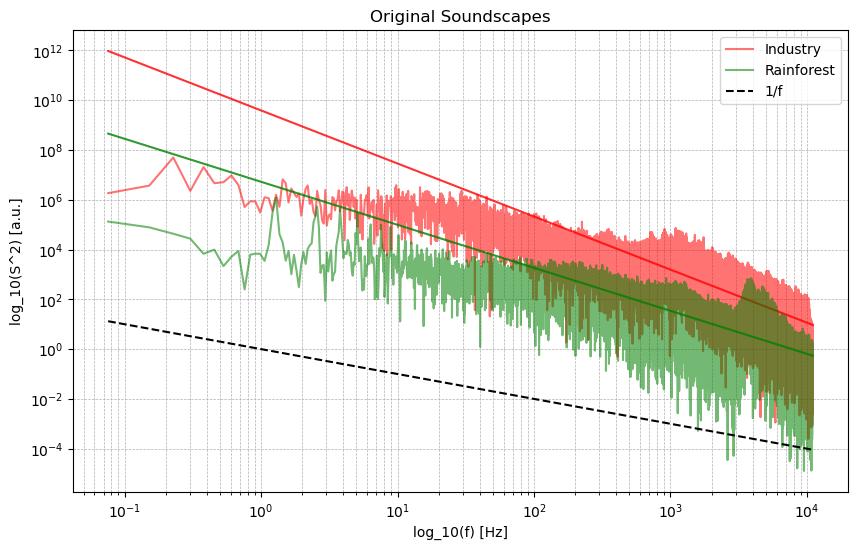

In [67]:
plt.figure(figsize=(10, 6)) 

print('Slope 1/f: -1')

###### INDUSTRY ######## 

# calculate spectrum of amplitude envelope
y = osa
analytic_signal = hilbert(y)
amplitude_envelope = np.abs(analytic_signal)
N = len(amplitude_envelope)
frequencies = np.fft.rfftfreq(N, d=1/sr)
power_spectrum = np.abs(np.fft.rfft(amplitude_envelope))**2

# plot power spectrum
plt.loglog(frequencies[1:], power_spectrum[1:], alpha = 0.55, color='r', label = 'Industry')

# Linear Regression to find slope
log_freq = np.log10(frequencies[1:])
log_power = np.log10(power_spectrum[1:])
slope, intercept, _, _, _ = linregress(log_freq, log_power)
fit_line = 10**(intercept + slope * log_freq)

# plot linear fit
plt.loglog(frequencies[1:], fit_line, color='r', alpha=0.8)
print('Slope of Industry Envelope: ' + str(slope))


####### RAINFOREST ######### 

# calculate spectrum of amplitude envelope
y = rain
analytic_signal = hilbert(y)
amplitude_envelope = np.abs(analytic_signal)
N = len(amplitude_envelope)
frequencies = np.fft.rfftfreq(N, d=1/sr)
power_spectrum = np.abs(np.fft.rfft(amplitude_envelope))**2

# plot power spectrum
plt.loglog(frequencies[1:], power_spectrum[1:], alpha = 0.55, color = 'g', label = 'Rainforest')

# Linear regression to find slope
log_freq = np.log10(frequencies[1:])
log_power = np.log10(power_spectrum[1:])
slope, intercept, _, _, _ = linregress(log_freq, log_power)

# Linear fit
fit_line = 10**(intercept + slope * log_freq)
plt.loglog(frequencies[1:], fit_line, color='g', alpha=0.8)

print('Slope of Jungle Envelope: ' + str(slope))


# plot
plt.grid(True, which="both", linestyle="--", linewidth=0.5)
plt.loglog(frequencies[1:], 1/frequencies[1:], 'k--', label="1/f")
plt.xlabel("log_10(f) [Hz]")
plt.ylabel("log_10(S^2) [a.u.]")
plt.title("Original Soundscapes")
plt.legend()
plt.savefig('Non-Chimera Power Spectrum.png')
plt.show()


## Chimera Soundscapes

Slope 1/f: -1
Slope of Industry Envelope: -2.294244096180168
Slope of Jungle Envelope: -1.5572144073681828


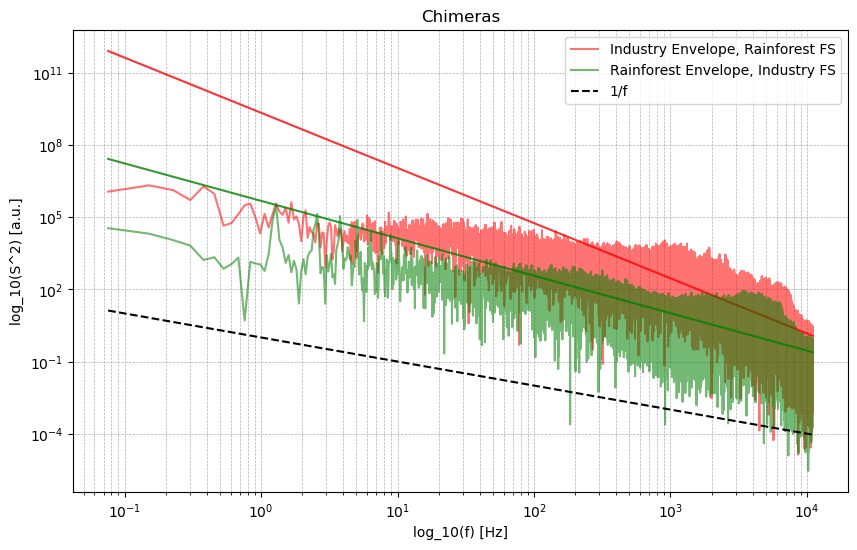

In [73]:
# example taken: Jungle and Industry - different class chimeras
nat_env, mac_env = chimera.generate(rain, osa, bands, sr)

plt.figure(figsize=(10, 6)) 

print('Slope 1/f: -1')

###### INDUSTRY ######## machine envelope + natural fine structure

# calculate spectrum of amplitude envelope
y = mac_env
analytic_signal = hilbert(y)
amplitude_envelope = np.abs(analytic_signal)
N = len(amplitude_envelope)
frequencies = np.fft.rfftfreq(N, d=1/sr)
power_spectrum = np.abs(np.fft.rfft(amplitude_envelope))**2

# plot power spectrum
plt.loglog(frequencies[1:], power_spectrum[1:], alpha = 0.55, color='r', label = 'Industry Envelope, Rainforest FS')

# Linear Regression to find slope
log_freq = np.log10(frequencies[1:])
log_power = np.log10(power_spectrum[1:])
slope, intercept, _, _, _ = linregress(log_freq, log_power)
fit_line = 10**(intercept + slope * log_freq)

# plot linear fit
plt.loglog(frequencies[1:], fit_line, color='r', alpha=0.8)
print('Slope of Industry Envelope: ' + str(slope))

#rmsd = np.sqrt(np.mean((power_spectrum[1:] - 1/frequencies[1:]) ** 2))
#print('RMSD Machine Envelope:' + str(rmsd))

####### JUNGLE ######### natural envelope and machine fine structure

# calculate spectrum of amplitude envelope
y = nat_env
analytic_signal = hilbert(y)
amplitude_envelope = np.abs(analytic_signal)
N = len(amplitude_envelope)
frequencies = np.fft.rfftfreq(N, d=1/sr)
power_spectrum = np.abs(np.fft.rfft(amplitude_envelope))**2

# plot power spectrum
plt.loglog(frequencies[1:], power_spectrum[1:], alpha = 0.55, color = 'g', label = 'Rainforest Envelope, Industry FS')

# Linear regression to find slope
log_freq = np.log10(frequencies[1:])
log_power = np.log10(power_spectrum[1:])
slope, intercept, _, _, _ = linregress(log_freq, log_power)

# Linear fit
fit_line = 10**(intercept + slope * log_freq)
plt.loglog(frequencies[1:], fit_line, color='g', alpha=0.8)

print('Slope of Jungle Envelope: ' + str(slope))

#rmsd = np.sqrt(np.mean((power_spectrum[1:] - 1/frequencies[1:]) ** 2))
#print('RMSD Natural Envelope:' + str(rmsd))

# plot
plt.grid(True, which="both", linestyle="--", linewidth=0.5)
plt.loglog(frequencies[1:], 1/frequencies[1:], 'k--', label="1/f")
plt.xlabel("log_10(f) [Hz]")
plt.ylabel("log_10(S^2) [a.u.]")
plt.title("Chimeras")
plt.legend()
plt.savefig('Chimeras Power Spectrum.png')
plt.show()
